# Week 2 Homework — Data Manipulation & Visualization (Pandas + Finance)

This homework reinforces the main Week 2 concepts:
- Data I/O (CSV/Excel)
- Dealing with Missing Data
- GroupBy & Aggregations
- Merging, Joining, and Concatenating

In [1]:
# Setup: imports and helper paths
import pandas as pd
import numpy as np
from pathlib import Path
import pandas_datareader.data as web
from datetime import datetime, timedelta
import yfinance as yf


# Matplotlib (no custom styles/colors per course rules)
import matplotlib.pyplot as plt

# Display options (feel free to tweak)
pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 120)

import warnings
warnings.filterwarnings("ignore")


Run this code to fetch the data

In [2]:
import warnings

def load_prices(ticker):
    df = yf.download(tickers, period="6mo", interval="1d", auto_adjust=False, threads=True)
    if isinstance(df.columns, pd.MultiIndex):
        close = df["Close"].copy()
        close = close.reset_index().rename(columns={"Date":"date"})
        long = close.melt(id_vars="date", var_name="ticker", value_name="close")
        long["ticker"] = long["ticker"].astype(str)
        return long.sort_values(["ticker","date"]).reset_index(drop=True)

def load_fred(series):
    # Try pandas-datareader (if available)
    end = pd.Timestamp.today().normalize()
    start = end - pd.offsets.MonthBegin(8)
    fred_df = pd.DataFrame({s: web.DataReader(s, "fred", start, end)[s] for s in series})
    fred_df = fred_df.reset_index().rename(columns={"DATE":"date"})
    # Keep month-start dates
    fred_df["date"] = fred_df["date"].dt.to_period("M").dt.to_timestamp()
    fred_df = fred_df.groupby("date", as_index=False).last()
    return fred_df


def load_sector_map():
    return pd.DataFrame({"ticker":['XOM','TSLA','BAC'], "sector":["Energy", "Information Technology", "Banking"]})

tickers = ['XOM', 'TSLA']
series = ["CPIAUCSL","FEDFUNDS"]

prices = load_prices(tickers)
fred = load_fred(series)
sector_map = load_sector_map()

prices.head(), fred.head(), sector_map


[*********************100%***********************]  2 of 2 completed


(        date ticker       close
 0 2025-10-14   TSLA  429.239990
 1 2025-10-15   TSLA  435.149994
 2 2025-10-16   TSLA  428.750000
 3 2025-10-17   TSLA  439.309998
 4 2025-10-20   TSLA  447.429993,
         date  CPIAUCSL  FEDFUNDS
 0 2025-09-01   324.245      4.22
 1 2025-10-01       NaN      4.09
 2 2025-11-01   325.063      3.88
 3 2025-12-01   326.031      3.72
 4 2026-01-01   326.588      3.64,
   ticker                  sector
 0    XOM                  Energy
 1   TSLA  Information Technology
 2    BAC                 Banking)

## Problem 1 — Data I/O

1. Save `prices` to a CSV file named `prices_out.csv` in the current directory. 3. Also export `fred` to an Excel file named `fred_out.xlsx` (sheet name `macro`).

In [4]:
# Your work here
# 1) Save to CSV
prices.to_csv("prices_out.csv", index=True)

In [5]:
# 2) Save to Excel (sheet name 'macro')
fred.to_excel("fred_out.xlsx", index=True)
with pd.ExcelWriter("fred_out.xlsx") as writer:
    fred.to_excel(writer, sheet_name="macro")

## Problem 2 — GroupBy & Resampling

1. Resample **daily** close prices to **monthly** last-close values. 2. Compute **monthly returns** for each ticker. 3. Report the **mean** and **standard deviation** of monthly returns for each ticker using `groupby` on ticker columns. 4. Plot the monthly return time series for AAPL and MSFT on the same axes.

In [17]:
# Your work here
prices2 = prices.copy()
prices2["Month"] = prices["date"].dt.month
prices2.head()




,date,ticker,close,Month
0,2025-10-14,TSLA,429.239990,10
1,2025-10-15,TSLA,435.149994,10
2,2025-10-16,TSLA,428.750000,10
3,2025-10-17,TSLA,439.309998,10
4,2025-10-20,TSLA,447.429993,10


In [19]:
# Resample daily close prices to monthly last-close values
monthly_close = prices2.set_index('date').groupby('ticker')['close'].resample('M').last().reset_index()

# Compute monthly returns for each ticker
monthly_returns = monthly_close.copy()
monthly_returns['return'] = monthly_returns.groupby('ticker')['close'].pct_change()
monthly_returns = monthly_returns.dropna()
monthly_returns.head()

,ticker,date,close,return
1,TSLA,2025-11-30,430.170013,-0.057802
2,TSLA,2025-12-31,449.720001,0.045447
3,TSLA,2026-01-31,430.410004,-0.042938
4,TSLA,2026-02-28,402.510010,-0.064822
5,TSLA,2026-03-31,371.750000,-0.076420


In [20]:
# Compute mean and standard deviation of monthly returns by ticker
monthly_returns.groupby('ticker')['return'].agg(['mean', 'std'])

,mean,std
ticker,,
TSLA,-0.041422,0.044048
XOM,0.052914,0.094186


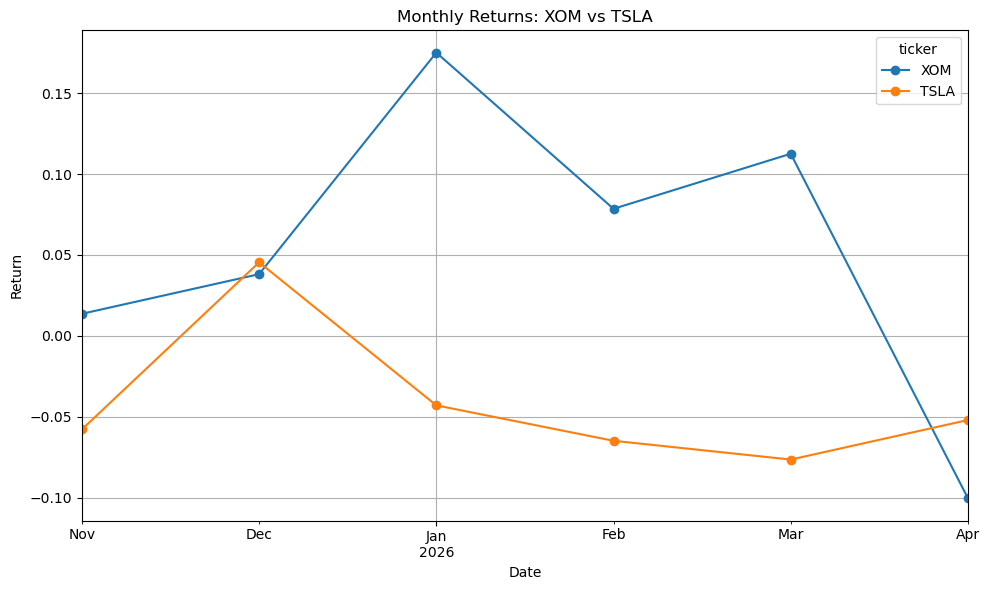

In [21]:
monthly_returns.pivot(index="date", columns="ticker", values="return")[["XOM", "TSLA"]].plot(
	figsize=(10, 6), marker="o"
)
plt.title("Monthly Returns: XOM vs TSLA")
plt.ylabel("Return")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()

## Problem 3 — Merging with Macro (FRED)

1. Merge monthly stock returns (from Problem 3) with monthly macro data (`fred`) on the `date` column. 2. Create a scatter plot of AAPL monthly returns vs the Fed Funds rate (`FEDFUNDS`). 3. Briefly comment on any visible relationship (or lack thereof).

In [22]:
#Your work here
# Merge monthly returns with fred data on 'date'
merged = pd.merge(monthly_returns, fred, on='date', how='left')
merged.head()

,ticker,date,close,return,CPIAUCSL,FEDFUNDS
0,TSLA,2025-11-30,430.170013,-0.057802,NaN,NaN
1,TSLA,2025-12-31,449.720001,0.045447,NaN,NaN
2,TSLA,2026-01-31,430.410004,-0.042938,NaN,NaN
3,TSLA,2026-02-28,402.510010,-0.064822,NaN,NaN
4,TSLA,2026-03-31,371.750000,-0.076420,NaN,NaN


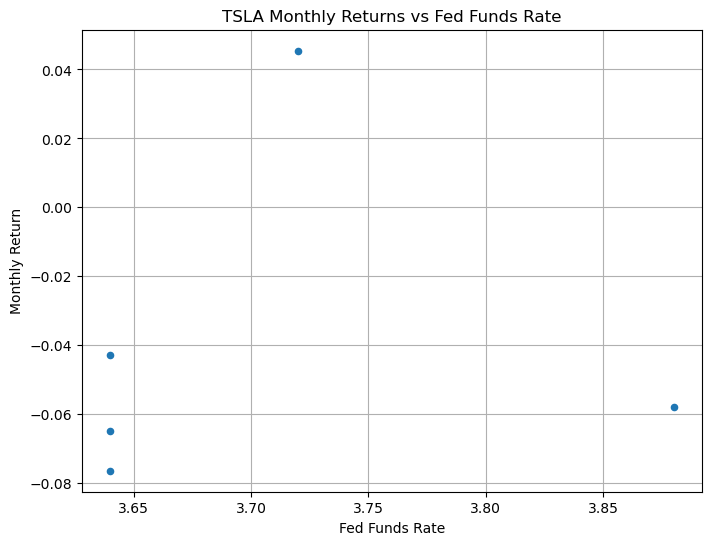

In [23]:
# Fix the merge by aligning dates to monthly periods
monthly_returns['period'] = monthly_returns['date'].dt.to_period('M')
fred['period'] = fred['date'].dt.to_period('M')

# Merge on period
merged_fixed = pd.merge(monthly_returns, fred[['period', 'FEDFUNDS']], on='period', how='left')

# Create scatter plot for TSLA monthly returns vs FEDFUNDS
merged_fixed[merged_fixed['ticker'] == 'TSLA'].plot.scatter(x='FEDFUNDS', y='return', figsize=(8, 6))
plt.title('TSLA Monthly Returns vs Fed Funds Rate')
plt.xlabel('Fed Funds Rate')
plt.ylabel('Monthly Return')
plt.grid(True)
plt.show()

The relationship between Tesla stock and the Fed Funds rate is interesting. It seems as though when the Fed has more volatile rates, Tesla appears to have negative returns. It seems Tesla is most likely to have good returns when rates are within normal range.